<a href="https://colab.research.google.com/github/Sneha-code01/ML/blob/main/battery_life_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Hawaii Natural Energy Institute examined 14 NMC-LCO 18650 batteries with a nominal capacity of 2.8 Ah, which were cycled over 1000 times at 25°C with a CC-CV charge rate of C/2 rate and discharge rate of 1.5C.

From that source dataset, I created features that showcase the voltage and current behaviour over each cycle. Those features can be used to predict the remaining useful life (RUL) of the batteries. The dataset contains the summary of the 14 batteries.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Battery_RUL.csv")
print(df.head(4))


   Cycle_Index  Discharge Time (s)  Decrement 3.6-3.4V (s)  \
0          1.0             2595.30             1151.488500   
1          2.0             7408.64             1172.512500   
2          3.0             7393.76             1112.992000   
3          4.0             7385.50             1080.320667   

   Max. Voltage Dischar. (V)  Min. Voltage Charg. (V)  Time at 4.15V (s)  \
0                      3.670                    3.211           5460.001   
1                      4.246                    3.220           5508.992   
2                      4.249                    3.224           5508.993   
3                      4.250                    3.225           5502.016   

   Time constant current (s)  Charging time (s)   RUL  
0                    6755.01           10777.82  1112  
1                    6762.02           10500.35  1111  
2                    6762.02           10420.38  1110  
3                    6762.02           10322.81  1109  


In [3]:
print(df.iloc[:,8])

0        1112
1        1111
2        1110
3        1109
4        1107
         ... 
15059       4
15060       3
15061       2
15062       1
15063       0
Name: RUL, Length: 15064, dtype: int64


In [4]:
#linear regression
import numpy as np

# Feature (column 0)
X = df.iloc[:,0].values.reshape(-1,1)

# Add bias column
X = np.hstack((np.ones((X.shape[0],1)), X))

# Target (column 8)
Y = df.iloc[:,8].values.reshape(-1,1)


def model(X, Y, learning_rate, iteration):

    # Initialize parameters
    theta = np.zeros((2,1))

    # Number of training examples
    m = len(Y)

    for i in range(iteration):

        # Prediction
        Y_pred = np.dot(X, theta)

        # Cost
        cost = (1/(2*m))*np.sum((Y_pred - Y)**2)

        # Gradient
        d_theta = (1/m)*np.dot(X.T, (Y_pred - Y))

        # Update parameters
        theta = theta - learning_rate*d_theta

    return theta


In [5]:
lr = 0.000001
itr = 280000

theta = model(X, Y, lr, itr)

print("Theta:")
print(theta)

Theta:
[[75.49468909]
 [ 0.39280307]]


In [6]:
Y_pred = np.dot(X, theta)

print(Y_pred)

[[ 75.88749216]
 [ 76.28029524]
 [ 76.67309831]
 ...
 [511.50610034]
 [511.89890341]
 [512.29170648]]


In [7]:
for i in range(10):
    print("Actual:", Y[i][0], "Predicted:", Y_pred[i][0])

Actual: 1112 Predicted: 75.88749216330739
Actual: 1111 Predicted: 76.28029523650196
Actual: 1110 Predicted: 76.67309830969654
Actual: 1109 Predicted: 77.06590138289113
Actual: 1107 Predicted: 77.85150752928028
Actual: 1106 Predicted: 78.24431060247487
Actual: 1105 Predicted: 78.63711367566945
Actual: 1104 Predicted: 79.02991674886403
Actual: 1103 Predicted: 79.42271982205861
Actual: 1102 Predicted: 79.8155228952532


In [8]:
print(Y.shape)
print(Y_pred.shape)

(15064, 1)
(15064, 1)


In [9]:
print(df.iloc[:,[0,1,7]].shape)
print(df.iloc[:,8].shape)


(15064, 3)
(15064,)


In [11]:
import numpy as np

# Features
S = df.iloc[:, [0,1,7]].values

# Adding bias column
S = np.hstack((np.ones((S.shape[0],1)), S))

# Target
a = df.iloc[:,8].values.reshape(-1,1)

#normalizing so that gradient descent work efficiently
from sklearn.preprocessing import StandardScaler

S = df.iloc[:, [0,1,7]].values
a = df.iloc[:,8].values.reshape(-1,1)

scaler = StandardScaler()
S = scaler.fit_transform(S)
S = np.hstack((np.ones((S.shape[0],1)), S))

# Train-test split
from sklearn.model_selection import train_test_split

S_train, S_test, a_train, a_test = train_test_split(
    S,
    a,
    test_size=0.2,
    random_state=42
)

def model(S, a, learn_rate, repeat):

    m = len(a)

    # 4 parameters because 3 features + 1 bias
    theta = np.zeros((4,1))

    for i in range(repeat):

        # Prediction
        a_pred = np.dot(S, theta)

        # Cost
        cost_func = (1/(2*m))*np.sum((a_pred - a)**2)

        # Gradient
        d_theta = (1/m)*(S.T @ (a_pred - a))

        # Update
        theta = theta - learn_rate*d_theta

    return theta

In [12]:
learn = 0.005
step = 8500
#training it
theta = model(S_train,a_train,learn,step)
print(theta)

[[ 5.54163318e+02]
 [-3.22362290e+02]
 [ 6.91964630e-02]
 [-2.95475194e-02]]


In [13]:
a_pred = np.dot(S_test, theta)
for i in range(10):
    print("Actual:", a_test[i][0], "Predicted:", a_pred[i][0])

Actual: 1043 Predicted: 1045.305889797276
Actual: 956 Predicted: 932.3078971011217
Actual: 469 Predicted: 474.3153849202589
Actual: 176 Predicted: 172.32009761098993
Actual: 943 Predicted: 948.3076498050306
Actual: 617 Predicted: 622.3131856041082
Actual: 207 Predicted: 209.31961624685692
Actual: 32 Predicted: 34.32278835925604
Actual: 23 Predicted: 25.322918561288702
Actual: 22 Predicted: 27.322876695034097


r2 score: 0.9994738726997054


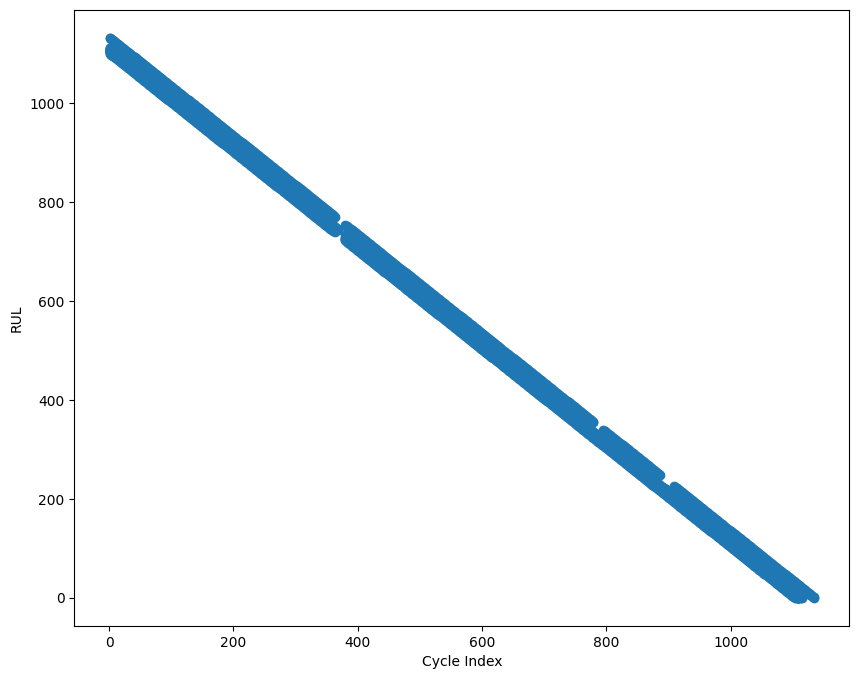

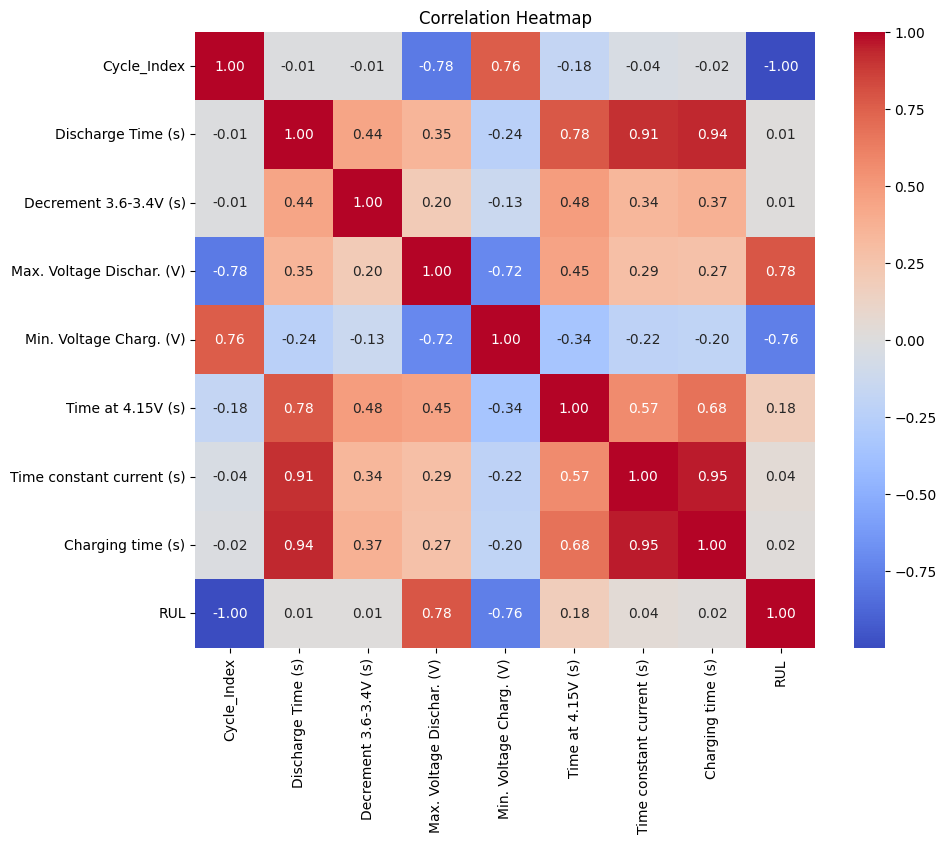

In [21]:
y_bar = np.sum(a_test)/len(a_test)
y_act = a_test
y_pred = a_pred
#r2 score
r2 = 1 - (np.sum(np.square(y_act-y_pred))/np.sum(np.square(y_act-y_bar)))
print("r2 score:", r2)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
plt.scatter(df['Cycle_Index'], df['RUL'])
plt.xlabel('Cycle Index')
plt.ylabel('RUL')
plt.show()
import seaborn as sns
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [23]:
corr_with_rul = df.corr(numeric_only=True)['RUL']

print(corr_with_rul.sort_values(ascending=False))


RUL                          1.000000
Max. Voltage Dischar. (V)    0.782800
Time at 4.15V (s)            0.176514
Time constant current (s)    0.040675
Charging time (s)            0.018299
Decrement 3.6-3.4V (s)       0.011998
Discharge Time (s)           0.011957
Min. Voltage Charg. (V)     -0.759805
Cycle_Index                 -0.999756
Name: RUL, dtype: float64


In [24]:
#linear regression for better result

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Features
S = df[
[
'Max. Voltage Dischar. (V)',
'Min. Voltage Charg. (V)',
'Time at 4.15V (s)'
]
]

# Target
a = df['RUL']

# Train-Test Split
S_train, S_test, a_train, a_test = train_test_split(
    S,
    a,
    test_size=0.2,
    random_state=42
)

# Model
lr = LinearRegression()

# Training
lr.fit(S_train, a_train)

# Prediction
a_pred = lr.predict(S_test)

# Metrics
print("R2 Score :", r2_score(a_test, a_pred))
print("MAE      :", mean_absolute_error(a_test, a_pred))
print("RMSE     :", np.sqrt(mean_squared_error(a_test, a_pred)))

R2 Score : 0.6764071820917132
MAE      : 110.57978038341726
RMSE     : 183.08347774045097


R2 Score : 0.9886519908905029
MAE      : 21.005756378173828
RMSE     : 34.28545332309772


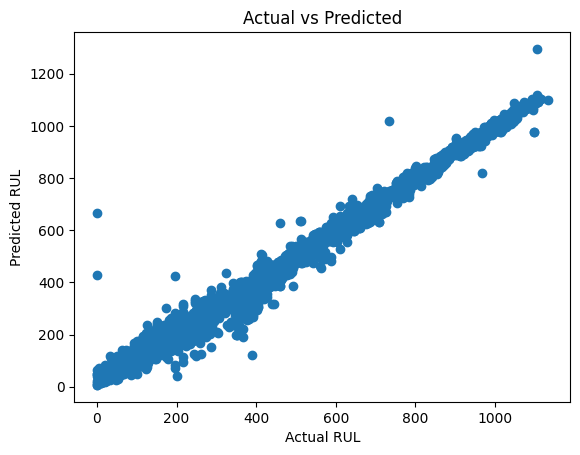

In [26]:
#xgboost method of ml
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor

# Features
S = df.drop(columns=['Cycle_Index', 'RUL'])

# Target
a = df['RUL']

# Train-Test Split
S_train, S_test, a_train, a_test = train_test_split(
    S,
    a,
    test_size=0.2,
    random_state=42
)

# Model
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# Training
xgb.fit(S_train, a_train)

# Prediction
a_pred = xgb.predict(S_test)

# Metrics
print("R2 Score :", r2_score(a_test, a_pred))
print("MAE      :", mean_absolute_error(a_test, a_pred))
print("RMSE     :", np.sqrt(mean_squared_error(a_test, a_pred)))
plt.scatter(a_test, a_pred)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted")

plt.show()

In [32]:
sample = S_test.iloc[0:1]

print("Actual RUL:", a_test.iloc[0])

print("Predicted RUL:", xgb.predict(sample)[0])


Actual RUL: 1043
Predicted RUL: 1047.9229


In [36]:
import numpy as np

# Feature names (same order as training)
features = [
    'Max. Voltage Dischar. (V)',
    'Min. Voltage Charg. (V)',
    'Time at 4.15V (s)',
    'Time constant current (s)',
    'Charging time (s)',
    'Decrement 3.6-3.4V (s)',
    'Discharge Time (s)'
]

for col in features:
    print(
        f"{col}: "
        f"{df[col].min():.2f} to {df[col].max():.2f}"
    )
# Take input from user
max_v = float(input("Enter Max Voltage Discharge(V): "))
min_v = float(input("Enter Min Voltage Charge(V): "))
time_415 = float(input("Enter Time at 4.15V(s): "))
time_cc = float(input("Enter Time Constant Current(s): "))
charge_time = float(input("Enter Charging Time(s): "))
decrement = float(input("Enter Decrement 3.6-3.4V Time(s): "))
discharge_time = float(input("Enter Discharge Time(s): "))

# Create input array
user_data = np.array([[
    max_v,
    min_v,
    time_415,
    time_cc,
    charge_time,
    decrement,
    discharge_time
]])

# Check training range
print("\nChecking input ranges...\n")

for i, col in enumerate(features):

    min_val = df[col].min()
    max_val = df[col].max()

    if user_data[0][i] < min_val or user_data[0][i] > max_val:

        print(
            f"⚠ Warning: {col} is outside training range "
            f"({min_val:.2f} to {max_val:.2f})"
        )

    else:

        print(
            f"✓ {col} is within range "
            f"({min_val:.2f} to {max_val:.2f})"
        )
# Predict RUL
predicted_rul = xgb.predict(user_data)

print("\nPredicted RUL =", round(predicted_rul[0], 2))

Max. Voltage Dischar. (V): 3.04 to 4.36
Min. Voltage Charg. (V): 3.02 to 4.38
Time at 4.15V (s): -113.58 to 245101.12
Time constant current (s): 5.98 to 880728.10
Charging time (s): 5.98 to 880728.10
Decrement 3.6-3.4V (s): -397645.91 to 406703.77
Discharge Time (s): 8.69 to 958320.37
Enter Max Voltage Discharge(V): 3.6
Enter Min Voltage Charge(V): 4
Enter Time at 4.15V(s): 6000
Enter Time Constant Current(s): 10000
Enter Charging Time(s): 8000
Enter Decrement 3.6-3.4V Time(s): 5000
Enter Discharge Time(s): 5000

Checking input ranges...

✓ Max. Voltage Dischar. (V) is within range (3.04 to 4.36)
✓ Min. Voltage Charg. (V) is within range (3.02 to 4.38)
✓ Time at 4.15V (s) is within range (-113.58 to 245101.12)
✓ Time constant current (s) is within range (5.98 to 880728.10)
✓ Charging time (s) is within range (5.98 to 880728.10)
✓ Decrement 3.6-3.4V (s) is within range (-397645.91 to 406703.77)
✓ Discharge Time (s) is within range (8.69 to 958320.37)

Predicted RUL = 200.43
